In [17]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import normalize

from visualization.plot import plot_clustering_on_umap
from visualization.samples_plot import show_clustering_samples
from clustering.hdbscan.consensus import consensus_clustering_from_labels_hdbscan
from clustering.hdbscan.consensus_dbcv import dbcv_per_cluster_consensus

PROJECT_ROOT = Path.cwd().resolve().parent
EMBEDDING_DIR = PROJECT_ROOT / "data" / "glomeruli" / "embeddings"

EMBEDDING_NAME = "densenet_crops_embeddings_224"

embedding: np.ndarray = np.load(EMBEDDING_DIR / f"{EMBEDDING_NAME}.npy")
csv = pd.read_csv(EMBEDDING_DIR / f"{EMBEDDING_NAME}.csv")
print(embedding.shape[1])
n_samples = embedding.shape[0]

1664


In [18]:
#X_reduced_variance = VarianceThreshold(threshold=1e-8).fit_transform(embedding)

#embedding_scaled = StandardScaler().fit_transform(X_reduced_variance)
embedding_l2 = normalize(embedding, norm="l2")

pca_85 = PCA(n_components=0.85)
pca_85_embedding = pca_85.fit_transform(embedding_l2)

#print("Shape dopo PCA:", pca_95_embedding.shape)

#pca_95_embedding_l2 = normalize(pca_95_embedding, norm="l2")

#pca_100_embedding_l2 = normalize(pca_100_embedding, norm="l2")

In [19]:
from clustering.hdbscan.score import consensus_param_score, consensus_param_metrics
import pandas as pd
from tqdm.auto import tqdm

from clustering.hdbscan.fit import fit_umap_hdbscan
from clustering.hdbscan.params import make_umap_hdbscan_grid_params

params = make_umap_hdbscan_grid_params(
    # Rimaniamo su dimensioni basse (2D e 3D) per non annullare la densità
    n_components_values=[10],

    # n_neighbors: dall'1.5% al 5% del dataset
    n_neighbors_values=[
        #int(0.02 * n_samples),  # Con 677 → 10 | Scala a 150 su 10k
        int(0.03 * n_samples),   # Con 677 → 20 | Scala a 300 su 10k
        int(0.05 * n_samples)    # Con 677 → 33 | Scala a 500 su 10k
    ],

    # min_cluster_size: dallo 0.8% al 3% del dataset
    min_cluster_size_values=[
        #int(0.008 * n_samples),   # Con 677 → 5  | Trova fenotipi rari dello 0.8%
        int(0.015 * n_samples),  # Con 677 → 10
        int(0.03 * n_samples),    # Con 677 → 20
        int(0.04 * n_samples)
    ],

    # min_samples: frazioni molto piccole o valori fissi per il controllo del rumore
    min_samples_values=[                             # Massimo dettaglio, zero restrizioni sulla forma
        3,
        5,# Ottimo compromesso per dataset sotto i 1000 punti
        7
        #int(0.007 * n_samples)    # Con 677 → 5  | Diventa conservativo sui grandi numeri
    ]
)

candidate_results = []

for config_id, param in enumerate(tqdm(params, desc="Grid search consensus")):
    labels_for_consensus = []
    umap_embeddings_for_consensus = []

    for seed in range(0, 30):
        labels, umap_embedding = fit_umap_hdbscan(
            X=pca_85_embedding,
            seed=None,
            n_components=param["n_components"],
            n_neighbors=param["n_neighbors"],
            min_dist=0.00,
            #umap_metric="cosine",
            min_cluster_size=param["min_cluster_size"],
            min_samples=param["min_samples"],
        )

        labels_for_consensus.append(labels)
        umap_embeddings_for_consensus.append(umap_embedding)

    consensus_labels, probabilities = consensus_clustering_from_labels_hdbscan(
        labels_for_consensus,
        max_noise_frequency=0.33,
        min_consensus_strength=0.70,
    )

    dbcv_consensus = dbcv_per_cluster_consensus(
        consensus_labels,
        umap_embeddings_for_consensus,
    )

    score = consensus_param_score(
        dbcv_df=dbcv_consensus,
        consensus_labels=consensus_labels,
        max_noise=0.25,
    )

    metrics = consensus_param_metrics(
        dbcv_df=dbcv_consensus,
        consensus_labels=consensus_labels,
    )

    candidate_results.append({
        "config_id": config_id,
        **param,
        "score": score,
        **metrics,
        "consensus_labels": consensus_labels,
        "probabilities": probabilities,
        "dbcv_df": dbcv_consensus,
    })

Grid search consensus:   0%|          | 0/18 [00:00<?, ?it/s]

In [20]:
results_df = pd.DataFrame([
    {
        k: v
        for k, v in result.items()
        if k not in ["consensus_labels", "probabilities", "dbcv_df"]
    }
    for result in candidate_results
])

results_df = results_df.sort_values("score", ascending=False).reset_index(drop=True)

In [21]:
best_config_id = int(results_df.iloc[0]["config_id"])
best_result = candidate_results[best_config_id]

best_consensus_labels = best_result["consensus_labels"]
best_probabilities = best_result["probabilities"]
best_dbcv_df = best_result["dbcv_df"]

best_result_summary = {
    k: v
    for k, v in best_result.items()
    if k not in ["consensus_labels", "probabilities", "dbcv_df"]
}

best_result_summary

{'config_id': 8,
 'min_cluster_size': 20,
 'min_samples': 5,
 'n_components': 10,
 'n_neighbors': 20,
 'score': 0.3900724750225105,
 'n_clusters': 7,
 'noise_ratio': 0.1329394387001477,
 'global_dbcv_mean': 0.3992351043305328,
 'global_dbcv_std': 0.03665051723208891,
 'min_cluster_dbcv_median': 0.29263329280128814,
 'mean_cluster_dbcv_median': 0.42726194308763527}

In [22]:
best_cluster_dbcv = best_result["dbcv_df"]

display(
    best_cluster_dbcv[
        [
            "cluster",
            "size",
            "dbcv_mean",
            "dbcv_std",
            "dbcv_min",
            "dbcv_max",
            "dbcv_median",
            "n_runs_valid",
        ]
    ].sort_values("cluster").reset_index(drop=True)
)

,cluster,size,dbcv_mean,dbcv_std,dbcv_min,dbcv_max,dbcv_median,n_runs_valid
0,-1,90,NaN,NaN,NaN,NaN,NaN,0
1,0,33,0.391151,0.085248,0.173713,0.518043,0.400301,30
2,1,27,0.515412,0.081758,0.304069,0.640607,0.514123,30
3,2,52,0.447913,0.078275,0.286470,0.587226,0.460549,30
4,3,333,0.378628,0.059791,0.223299,0.495395,0.383356,30
5,4,52,0.492720,0.066719,0.364435,0.591264,0.489745,30
6,5,43,0.459820,0.071825,0.248052,0.609239,0.450127,30
7,6,47,0.271459,0.088604,0.081850,0.413417,0.292633,30


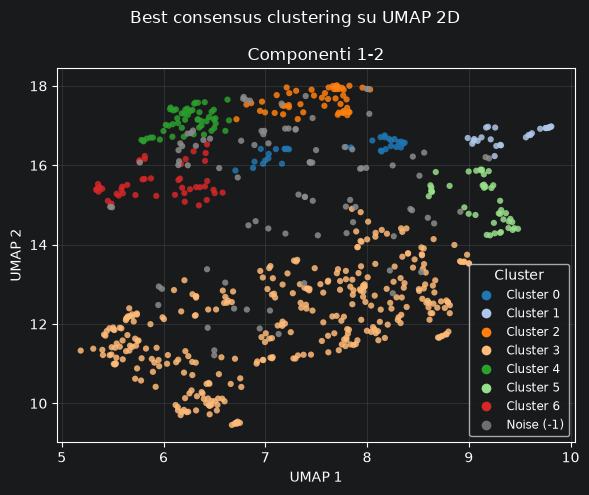

In [23]:
plot_figure, plot_axes = plot_clustering_on_umap(
    pca_85_embedding,
    best_consensus_labels,
    title="Best consensus clustering su UMAP 2D",
    metric="euclidean",
    min_dist=0.00,
    n_neighbors=int(best_result["n_neighbors"]),
)

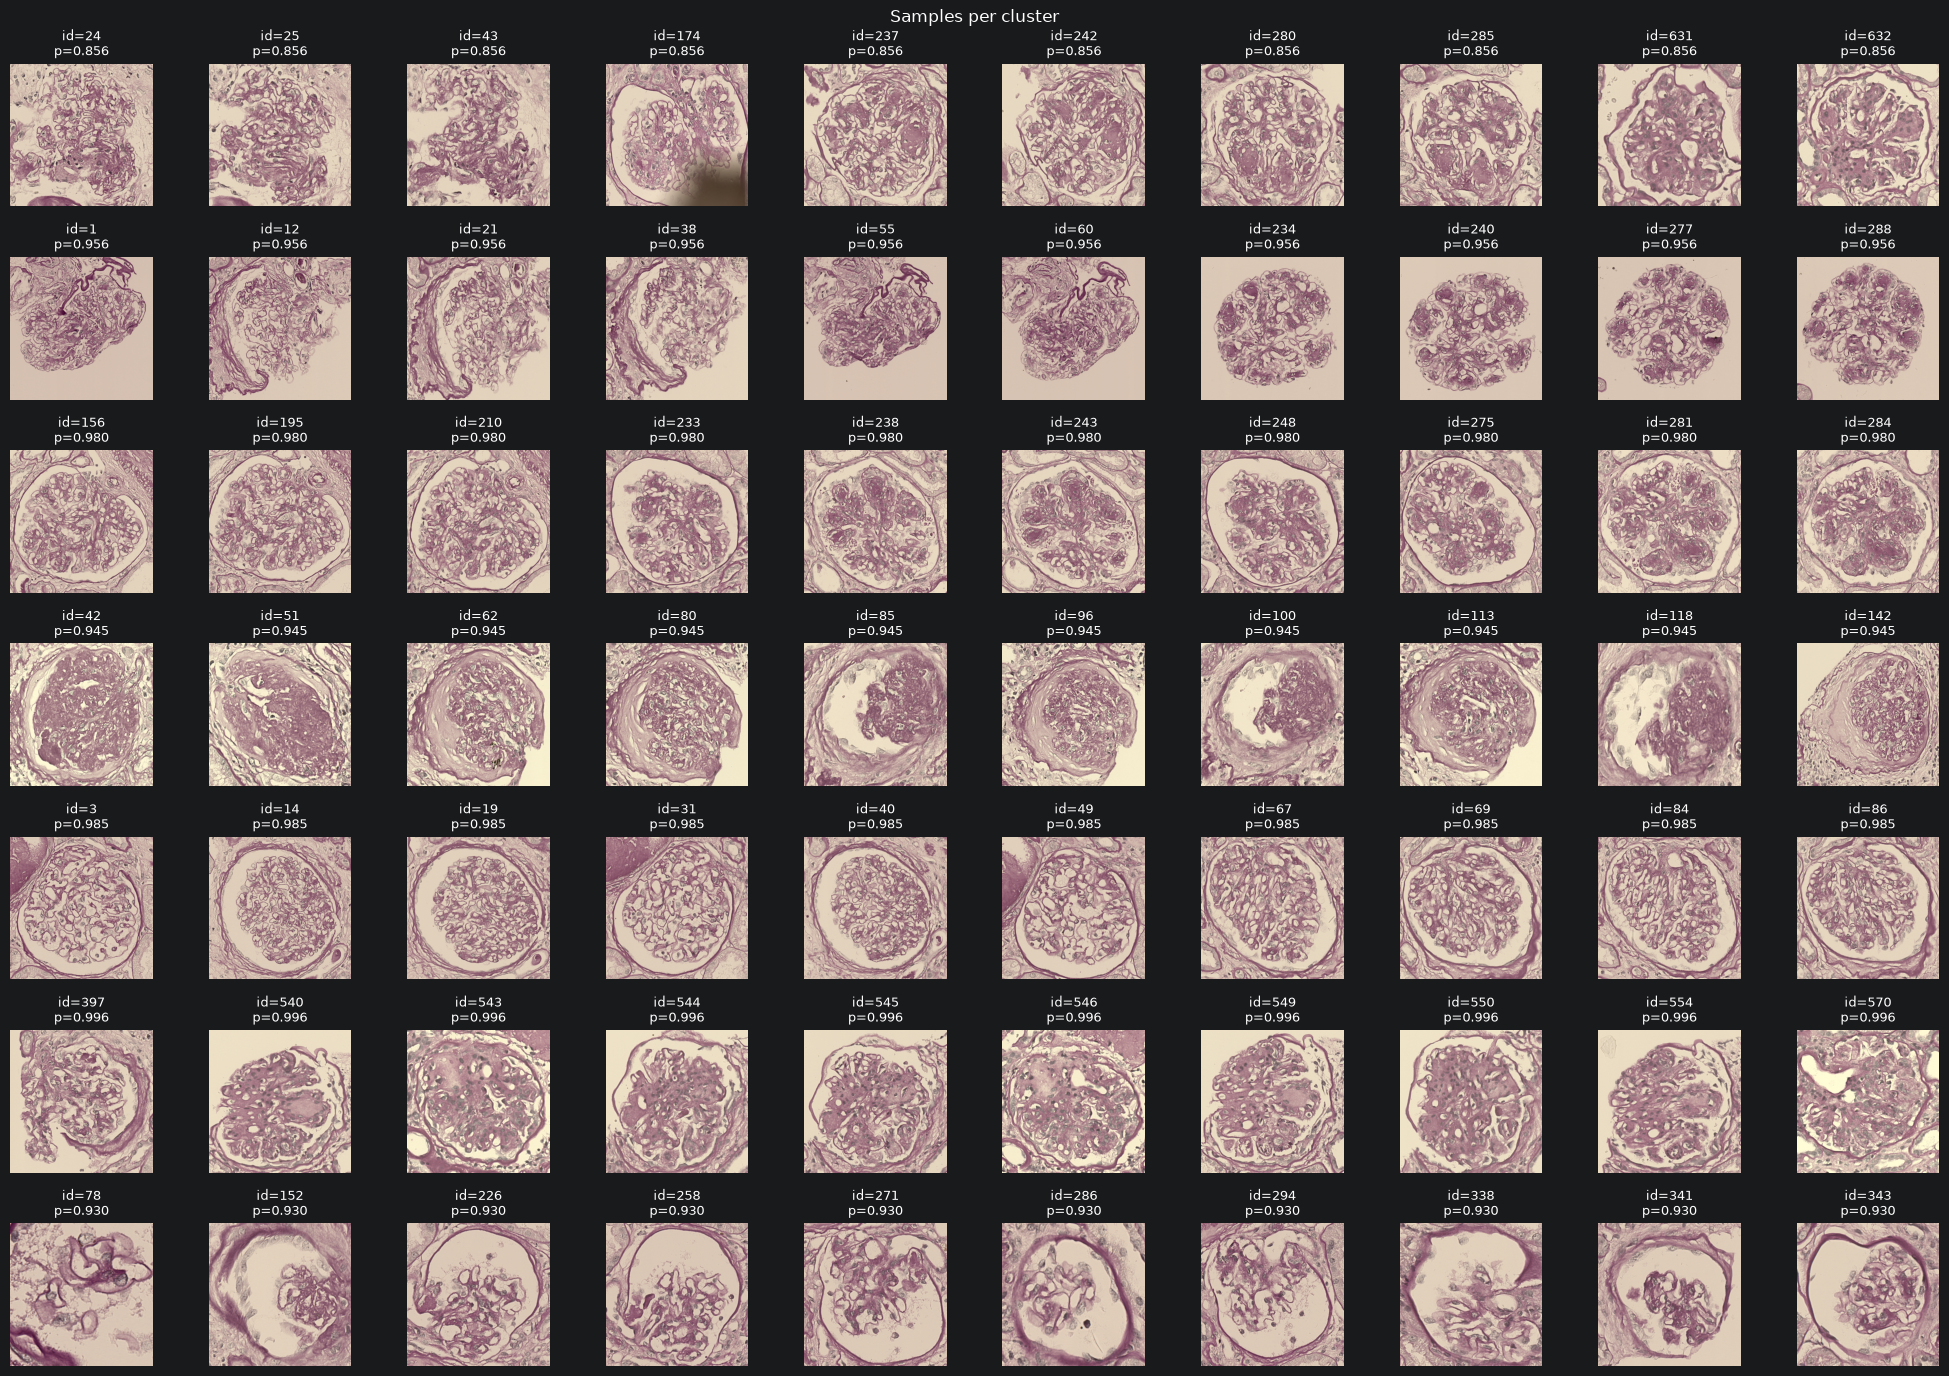

In [24]:
image_paths = csv["image_path"].tolist()

sample_figure, sample_axes = show_clustering_samples(
    labels=best_consensus_labels,
    probabilities=best_probabilities,
    image_paths=image_paths,
    x=10,
    base_dir=PROJECT_ROOT,
    image_size=2.0,
)

In [25]:
from sklearn.metrics import pairwise_distances


def pair_rank_report(X, idx_a, idx_b, metric="cosine", name="space"):
    """
    Dice quanto idx_b ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ vicino a idx_a nello spazio X.
    rank = 1 significa vicino pi﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ vicino.
    rank alto significa lontano.
    """
    D = pairwise_distances(X, X[[idx_a]], metric=metric).ravel()

    order = np.argsort(D)
    order = order[order != idx_a]  # rimuove s﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ stesso

    rank_b = np.where(order == idx_b)[0][0] + 1
    dist_ab = D[idx_b]

    percent_rank = rank_b / (len(X) - 1) * 100

    print(f"\n{name}")
    print(f"metric: {metric}")
    print(f"distanza {idx_a} -> {idx_b}: {dist_ab:.4f}")
    print(f"rank del secondo rispetto al primo: {rank_b}/{len(X) - 1}")
    print(f"percentile rank: {percent_rank:.2f}%")

    return {
        "space": name,
        "distance": dist_ab,
        "rank": rank_b,
        "percent_rank": percent_rank,
    }

In [26]:
ID_SCLEROTIC = 4
ID_OPEN = 3

In [27]:
# Distanza originale tra due punti nello spazio embedding
report_pre = pair_rank_report(
    embedding,
    ID_SCLEROTIC,
    ID_OPEN,
    metric="cosine",
    name="PRE-UMAP"
)


post_umap = pair_rank_report(
    umap_embedding,
    ID_SCLEROTIC,
    ID_OPEN,
    metric="euclidean",
    name="POST-UMAP"
)


PRE-UMAP
metric: cosine
distanza 4 -> 3: 0.2981
rank del secondo rispetto al primo: 224/676
percentile rank: 33.14%

POST-UMAP
metric: euclidean
distanza 4 -> 3: 2.0151
rank del secondo rispetto al primo: 127/676
percentile rank: 18.79%
